In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("diabetes_risk.csv")


In [6]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  str    
 3   city                      15000 non-null  str    
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  str    
 6   physical_activity_level   15000 non-null  str    
 7   diet_type                 15000 non-null  str    
 8   smoking_status            14528 non-null  str    
 9   alcohol_consumption       11212 non-null  str    
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_pressure_sy

In [7]:
df = df.drop("patient_id", axis=1)

In [10]:
print(df.isnull().sum())

age                            0
gender                         0
city                           0
bmi                            0
family_history_diabetes        0
physical_activity_level        0
diet_type                      0
smoking_status               472
alcohol_consumption         3788
hours_sleep_per_night          0
stress_level                   0
fasting_blood_sugar            0
hba1c_level                    0
blood_pressure_systolic        0
blood_pressure_diastolic       0
waist_circumference_cm         0
income_bracket               463
diabetes_risk                  0
dtype: int64


In [11]:
df.nunique()

age                          58
gender                        3
city                         18
bmi                         239
family_history_diabetes       2
physical_activity_level       3
diet_type                     4
smoking_status                3
alcohol_consumption           3
hours_sleep_per_night        73
stress_level                 10
fasting_blood_sugar         273
hba1c_level                  71
blood_pressure_systolic      89
blood_pressure_diastolic     58
waist_circumference_cm      614
income_bracket                3
diabetes_risk                 3
dtype: int64

In [ ]:
df["smoking_status"].value_counts() 

smoking_status
Never      10119
Current     2946
Former      1463
Name: count, dtype: int64

In [14]:
df['alcohol_consumption'].value_counts()

alcohol_consumption
Never         5616
Occasional    4483
Regular       1113
Name: count, dtype: int64

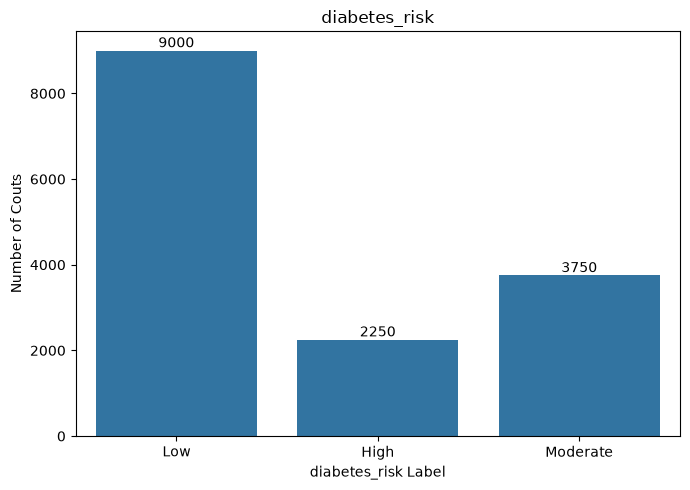

In [13]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df, x='diabetes_risk')
plt.title('diabetes_risk')
plt.xlabel('diabetes_risk Label')
plt.ylabel('Number of Couts')

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [15]:
object_columns = df.select_dtypes(include=['object', 'bool']).columns
print("Object type columns:")
print(object_columns)

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
print("\nNumerical type columns:")
print(numerical_columns)

Object type columns:
Index(['gender', 'city', 'family_history_diabetes', 'physical_activity_level',
       'diet_type', 'smoking_status', 'alcohol_consumption', 'income_bracket',
       'diabetes_risk'],
      dtype='str')

Numerical type columns:
Index(['age', 'bmi', 'hours_sleep_per_night', 'stress_level',
       'fasting_blood_sugar', 'hba1c_level', 'blood_pressure_systolic',
       'blood_pressure_diastolic', 'waist_circumference_cm'],
      dtype='str')


In [16]:
def classify_features(df):
    categorical_features = []
    non_categorical_features = []
    discrete_features = []
    continuous_features = []

    for column in df.columns:
        if df[column].dtype in ['object', 'bool']:
            if df[column].nunique() < 10:
                categorical_features.append(column)
            else:
                non_categorical_features.append(column)
        elif df[column].dtype in ['int64', 'float64']:
            if df[column].nunique() < 10:
                discrete_features.append(column)
            else:
                continuous_features.append(column)

    return categorical_features, non_categorical_features, discrete_features, continuous_features

In [17]:
categorical, non_categorical, discrete, continuous = classify_features(df)

In [18]:
print("Categorical Features:", categorical)
print("Non-Categorical Features:", non_categorical)
print("Discrete Features:", discrete)
print("Continuous Features:", continuous)

Categorical Features: []
Non-Categorical Features: []
Discrete Features: []
Continuous Features: ['age', 'bmi', 'hours_sleep_per_night', 'stress_level', 'fasting_blood_sugar', 'hba1c_level', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'waist_circumference_cm']


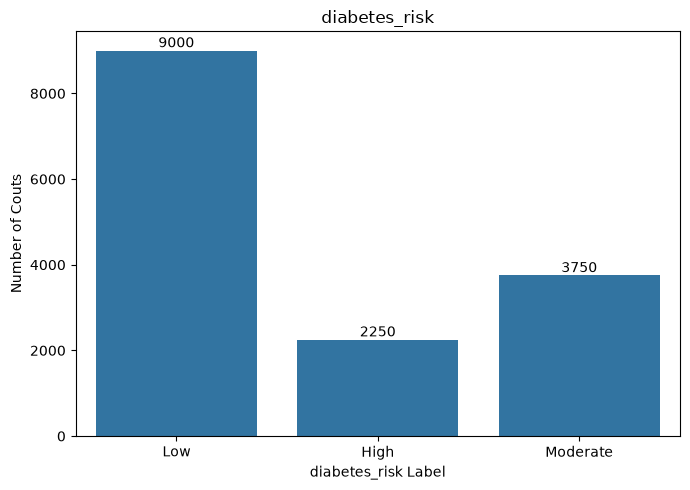

In [19]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df, x='diabetes_risk')
plt.title('diabetes_risk')
plt.xlabel('diabetes_risk Label')
plt.ylabel('Number of Couts')

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

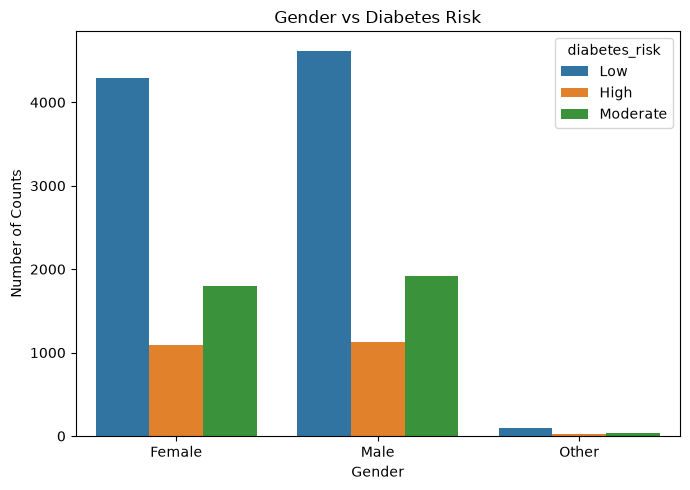

In [20]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='gender', hue='diabetes_risk')
plt.title('Gender vs Diabetes Risk')
plt.xlabel('Gender')
plt.ylabel('Number of Counts')
plt.tight_layout()
plt.show()